In [ ]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

In [ ]:
data = pd.read_csv(r"C:\Users\Boya Shalini\OneDrive\Desktop\Crop_recommendation.csv")


print(data.head())


print(data.info())

In [4]:
print(data.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [ ]:
le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])

In [20]:
print(data['label'].head())

# To see mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

0    20
1    20
2    20
3    20
4    20
Name: label, dtype: int64
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21}


In [10]:
X = data.drop('label', axis=1)
y = data['label']

In [21]:
print(X.head())   # features
print(y.head())   # target

    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340
0    20
1    20
2    20
3    20
4    20
Name: label, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1760, 7)
X_test shape: (440, 7)
y_train shape: (1760,)
y_test shape: (440,)


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
print(X_train[:5])  # first 5 rows after scaling

[[-0.9034266  -1.1261617  -0.6685066  -1.80469186  0.93658618  0.19347378
   0.0051497 ]
 [-0.36705134  0.77035885 -0.57058952  0.38599999 -0.10047048  0.86391755
  -0.60529057]
 [-1.17161422  0.58973784 -0.45308903  0.38167811 -0.38277499  1.05029771
  -1.04580687]
 [ 1.34934948  0.49942734 -0.00267047 -0.04304651  0.157688   -0.599105
   0.25287233]
 [-1.35934556 -1.0960582  -0.35517195  1.94456199 -1.0713034  -0.25452617
  -0.08865765]]


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

In [14]:
results = []

for name, model in models.items():
    start = time.time()
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    end = time.time()
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append([name, acc, prec, rec, f1, end-start])
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)


Logistic Regression
Accuracy: 0.9636363636363636
Precision: 0.9644420567548909
Recall: 0.9636363636363636
F1 Score: 0.9635115059268676

Decision Tree
Accuracy: 0.9840909090909091
Precision: 0.9845228256591892
Recall: 0.9840909090909091
F1 Score: 0.9840886431819624

Random Forest
Accuracy: 0.9931818181818182
Precision: 0.9937348484848485
Recall: 0.9931818181818182
F1 Score: 0.9931754816901672

SVM
Accuracy: 0.9681818181818181
Precision: 0.9715171192443921
Recall: 0.9681818181818181
F1 Score: 0.9680271341017991


In [15]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time"
])

print("\nComparison Table:")
print(results_df)


Comparison Table:
                 Model  Accuracy  Precision    Recall  F1 Score  Training Time
0  Logistic Regression  0.963636   0.964442  0.963636  0.963512       0.710366
1        Decision Tree  0.984091   0.984523  0.984091  0.984089       0.048885
2        Random Forest  0.993182   0.993735  0.993182  0.993175       0.857566
3                  SVM  0.968182   0.971517  0.968182  0.968027       0.287059


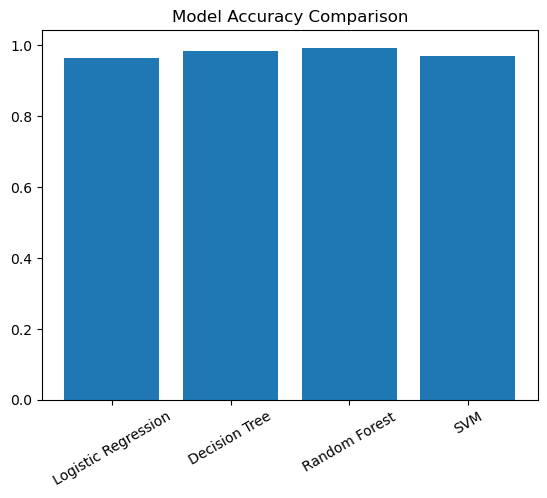

In [16]:
plt.figure()
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.show()

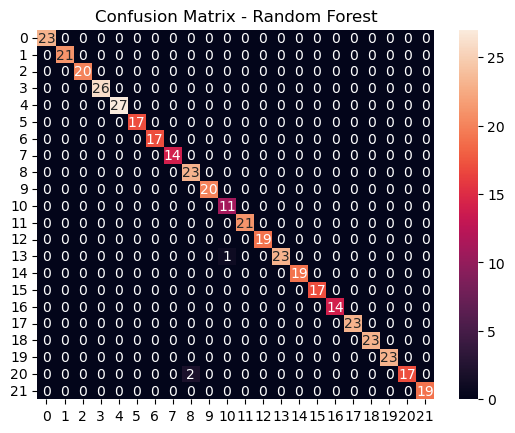

In [17]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [18]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(RandomForestClassifier(), X, y, cv=5)
print("Cross Validation Accuracy:", np.mean(cv_scores))

Cross Validation Accuracy: 0.9945454545454545


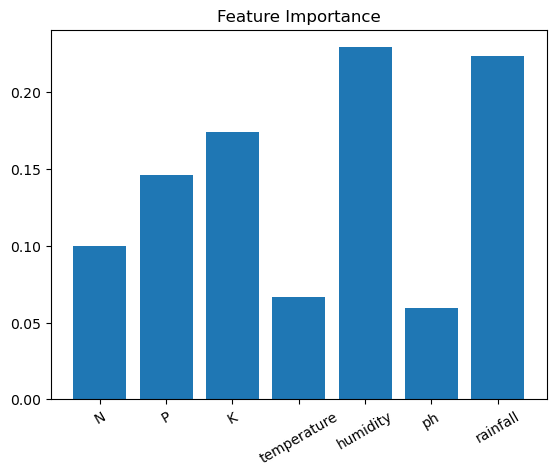

In [19]:
model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

plt.figure()
plt.bar(X.columns, importances)
plt.xticks(rotation=30)
plt.title("Feature Importance")
plt.show()